# Machine Learning models applied.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score, explained_variance_score

import scipy.stats as stats
from scipy.stats import kurtosis, boxcox

import mglearn
import matplotlib

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:/Users/elias/OneDrive/Desktop/MachineLearning/MLProject/Copia de DataBaseSGC.csv', delimiter=';', low_memory=False)
df

,Record Sequence Number,EQID,Epicenter Latitude (deg; positive N),Epicenter Longitude (deg; positive E),Hypocenter Depth (km),Magnitude,Magnitude type,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),...,Station Elevation (m),Tmax,Valor_T1.5,Repi_OpenQuake,Rjb_OpenQuake,Rrup_OpenQuake,Rx_OpenQuake,Rhypo_OpenQuake,Ry0_OpenQuake,T_0.01_RotD50
0,73,CO_20080524192044,4.374,-73.708,14.7,5.8671,Mw,Crustal,196,82,...,581.0,14,0.07,91.480436,85.352392,86.623229,5.748244,93.551751,85.165829,4.755494
1,74,CO_20100729193445,3.907,-75.097,33.1,5.0567,Mw,Crustal,37,54,...,581.0,15,0.05,96.319115,93.725261,99.461616,8.545095,102.497369,93.435791,10.887828
2,76,CO_19940913100134,7.105,-76.665,14.0,6.0202,Mw,Crustal,4,64,...,1472.0,2,0.09,180.238872,173.579980,174.684394,95.953705,181.353681,146.630792,4.847060
3,79,CO_19961104172500,7.364,-77.380,14.0,6.2562,Mw,Crustal,188,43,...,1472.0,2,0.10,253.961289,244.155697,244.405678,-188.792092,254.752031,154.796223,1.814338
4,84,CO_19990125181918,4.445,-75.659,17.0,6.1355,Mw,Crustal,8,65,...,1472.0,3,0.07,139.662026,134.252237,135.354859,-121.819668,141.709990,56.434882,9.462926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8806,8774,CO_20190331072713,-1.910,-80.810,5.0,5.6000,Mw,Interface,337,24,...,696.0,27,0.02,1236.021754,1230.674634,1230.049890,1178.334392,1236.043904,374.756057,0.004725
8807,8776,CO_20190331140913,-2.030,-80.890,10.0,5.0181,Mw,Interface,354,21,...,696.0,27,0.02,1253.442350,1249.197259,1248.234684,1023.671482,1253.495004,717.168683,0.003128
8808,8777,CO_20190408032300,-2.120,-80.360,47.0,5.0304,Mw,Interface,334,31,...,696.0,27,0.02,1216.435655,1213.141652,1209.579637,1162.208344,1217.416127,358.488368,0.003101
8809,8778,CO_20190409113955,3.750,-78.740,10.0,5.0266,Mw,Interface,26,32,...,696.0,20,0.02,729.062638,725.469563,725.018483,-469.472251,729.171353,552.584146,0.020313


In [3]:
#df["T_0.01_RotD50"]= df["T_0.01_RotD50"]/980

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Record Sequence Number,8811.0,4406.000000,2543.660944,1.000000,2203.500000,4406.000000,6608.500000,8811.000000
Epicenter Latitude (deg; positive N),8811.0,5.896834,3.759842,-4.825000,3.440000,6.535500,7.280000,13.260000
Epicenter Longitude (deg; positive E),8811.0,-76.241968,2.851960,-81.260000,-78.290000,-76.040000,-73.280000,-67.973000
Hypocenter Depth (km),8811.0,59.993065,62.345192,1.000000,10.000000,19.600000,132.000000,209.900000
Magnitude,8811.0,4.988405,0.675945,3.800000,4.500000,4.900000,5.260000,7.782200
Nodal Plane 1 Strike (deg),8811.0,177.660651,106.265249,2.000000,88.000000,168.000000,265.000000,360.000000
Nodal Plane 1 Dip (deg),8811.0,58.328567,23.395038,1.000000,41.000000,65.000000,80.000000,90.000000
Nodal Plane 1 Rake Angle (deg),8811.0,13.555783,109.983810,-180.000000,-69.000000,20.000000,107.000000,180.000000
Nodal Plane 2 Strike (deg),8811.0,169.453978,108.282067,0.000000,71.000000,172.000000,258.000000,360.000000
Nodal Plane 2 Dip (deg),8811.0,68.298604,16.069385,14.000000,58.000000,69.000000,82.000000,90.000000


In [5]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['EQID', 'Magnitude type',
       'Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)',
       'Style-of-Faulting (S; R; N; U)', 'Station ID', 'Station Code'],
      dtype='object')

In [6]:
df.drop(["Record Sequence Number"], axis=1, inplace=True)
df.drop(["Station ID"], axis=1, inplace=True)
df.drop(["Station Code"], axis=1, inplace=True)
df.drop(["Magnitude type"], axis=1, inplace=True)
df.drop(["EQID"], axis=1, inplace=True)
df.drop(["Valor_T1.5"], axis=1, inplace=True)
df.drop(["Tmax"], axis=1, inplace=True)
df.drop(["Epicenter Latitude (deg; positive N)"], axis=1, inplace=True)
df.drop(["Epicenter Longitude (deg; positive E)"], axis=1, inplace=True)
df.drop(["Station Latitude (deg positive N)"], axis=1, inplace=True)
df.drop(["Station Longitude (deg positive E)"], axis=1, inplace=True)

In [7]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)', 'Style-of-Faulting (S; R; N; U)'], dtype='object')

In [8]:
df = df[df['T_0.01_RotD50'] > 0]
#df = df[df['T_0.01_RotD50'] > 0.0001]

In [9]:
df_copy = df.copy()

In [10]:
X= df_copy.copy()

In [11]:
df_copy["T_0.01_RotD50"]= np.log(df_copy["T_0.01_RotD50"])


In [12]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
Hypocenter Depth (km),8809.0,60.004416,62.347718,1.000000,10.000000,20.000000,132.000000,209.900000
Magnitude,8809.0,4.988410,0.676019,3.800000,4.500000,4.900000,5.260000,7.782200
Nodal Plane 1 Strike (deg),8809.0,177.646838,106.261691,2.000000,88.000000,168.000000,265.000000,360.000000
Nodal Plane 1 Dip (deg),8809.0,58.327165,23.395052,1.000000,41.000000,65.000000,80.000000,90.000000
Nodal Plane 1 Rake Angle (deg),8809.0,13.527075,109.978298,-180.000000,-69.000000,20.000000,107.000000,180.000000
Nodal Plane 2 Strike (deg),8809.0,169.450335,108.280821,0.000000,71.000000,172.000000,258.000000,360.000000
Nodal Plane 2 Dip (deg),8809.0,68.298558,16.068522,14.000000,58.000000,69.000000,82.000000,90.000000
Nodal Plane 2 Rake Angle (deg),8809.0,18.633897,102.792576,-180.000000,-50.000000,18.000000,100.000000,177.000000
Fault Plane (1; 2; X),8809.0,1.440005,0.496416,1.000000,1.000000,1.000000,2.000000,2.000000
Station Elevation (m),8809.0,1192.927767,1107.990874,4.000000,234.000000,780.000000,1948.000000,4136.000000


In [13]:
Y=X[["T_0.01_RotD50"]].copy()
X.drop(["T_0.01_RotD50"],axis=1, inplace=True )


In [14]:
df_numerico = df_copy.select_dtypes(include=[float, int])


In [15]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Estandarizar datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
df_numerico.drop(["Fault Plane (1; 2; X)"], axis=1, inplace=True) #Se va a codificar dsp.
# Escalar las variables predictoras
df_scaled = pd.DataFrame(scaler_X.fit_transform(df_numerico.drop("T_0.01_RotD50", axis=1)), 
                         columns=df_numerico.drop("T_0.01_RotD50", axis=1).columns)
# Escalar la variable de respuesta
Aceleracion_escalada = scaler_y.fit_transform(df_numerico[["T_0.01_RotD50"]])  # Debe ser 2D
df_scaled["T_0.01_RotD50"] = Aceleracion_escalada.flatten()

In [16]:
df_scaled

,Hypocenter Depth (km),Magnitude,Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),Nodal Plane 1 Rake Angle (deg),Nodal Plane 2 Strike (deg),Nodal Plane 2 Dip (deg),Nodal Plane 2 Rake Angle (deg),Station Elevation (m),Repi_OpenQuake,Rjb_OpenQuake,Rrup_OpenQuake,Rx_OpenQuake,Rhypo_OpenQuake,Ry0_OpenQuake,T_0.01_RotD50
0,0.065582,0.519085,0.541899,0.910112,0.002778,0.294444,0.986842,0.481793,0.139642,0.049285,0.047258,0.041342,0.492622,0.043130,0.049300,0.727553
1,0.153662,0.315579,0.097765,0.595506,0.883333,0.430556,0.565789,0.630252,0.139642,0.051954,0.051893,0.048506,0.493464,0.048102,0.054087,0.770831
2,0.062231,0.557531,0.005587,0.707865,0.525000,0.750000,0.894737,0.932773,0.355276,0.098248,0.096107,0.090482,0.519776,0.091937,0.084880,0.728550
3,0.062231,0.616795,0.519553,0.471910,0.616667,0.177778,0.644737,0.851541,0.355276,0.138917,0.135183,0.129388,0.434061,0.132737,0.089607,0.677210
4,0.076592,0.586485,0.016760,0.719101,0.441667,0.297222,0.750000,0.075630,0.355276,0.075864,0.074332,0.068535,0.454221,0.069900,0.032669,0.763503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8804,0.019148,0.452011,0.935754,0.258427,0.655556,0.536111,0.736842,0.795518,0.167473,0.680668,0.681395,0.679396,0.845595,0.678214,0.216936,0.366315
8805,0.043083,0.305886,0.983240,0.224719,0.744444,0.488889,0.723684,0.759104,0.167473,0.690278,0.691650,0.689543,0.799038,0.687915,0.415149,0.344772
8806,0.220201,0.308975,0.927374,0.337079,0.708333,0.477778,0.605263,0.781513,0.167473,0.669863,0.671687,0.667973,0.840741,0.667859,0.207519,0.344306
8807,0.043083,0.308021,0.067039,0.348315,0.227778,0.597222,0.578947,0.266106,0.167473,0.401005,0.401675,0.397579,0.349570,0.396456,0.319876,0.442509


In [17]:
df_scaled.drop(["Nodal Plane 1 Rake Angle (deg)"], axis=1, inplace=True)
df_scaled.drop(["Nodal Plane 2 Rake Angle (deg)"], axis=1, inplace=True)
df_scaled.drop(["Nodal Plane 2 Dip (deg)"], axis=1, inplace=True)
df_scaled.drop(["Nodal Plane 2 Strike (deg)"], axis=1, inplace=True)
df_scaled.drop(["Rx_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Ry0_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Rhypo_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Rrup_OpenQuake"], axis=1, inplace=True)
df_scaled.drop(["Repi_OpenQuake"], axis=1, inplace=True)

In [18]:
# Codificar la variable categórica con OneHotEncoder
X_categorical = df_copy[['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)']].astype(str)

enc = OneHotEncoder(sparse_output=False)
X_encoded = enc.fit_transform(X_categorical)  # Devuelve un array listo para KNN

Y_categorical = df_copy[["Fault Plane (1; 2; X)"]].astype(str)

enc = OneHotEncoder(sparse_output=False)
Y_encoded = enc.fit_transform(Y_categorical)  

Z_categorical = df_copy[["Style-of-Faulting (S; R; N; U)"]].astype(str)

enc = OneHotEncoder(sparse_output=False)
Z_encoded = enc.fit_transform(Z_categorical)  

X_numerical = df_scaled.drop(columns=["T_0.01_RotD50"]).values

# Paso 3: Combinar características numéricas y codificadas
X_final = np.hstack((X_numerical, X_encoded,Y_encoded,Z_encoded))

y = df_scaled["T_0.01_RotD50"].values  


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.3, random_state=0)

In [20]:
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Hypocenter Depth (km),8809.0,0.282453,0.298457,0.0,0.043083,0.090953,0.627094,1.0
Magnitude,8809.0,0.298430,0.169760,0.0,0.175782,0.276229,0.366632,1.0
Nodal Plane 1 Strike (deg),8809.0,0.490634,0.296820,0.0,0.240223,0.463687,0.734637,1.0
Nodal Plane 1 Dip (deg),8809.0,0.644125,0.262866,0.0,0.449438,0.719101,0.887640,1.0
Station Elevation (m),8809.0,0.287737,0.268149,0.0,0.055663,0.187803,0.470474,1.0
Rjb_OpenQuake,8809.0,0.285114,0.198489,0.0,0.133736,0.239893,0.396430,1.0
T_0.01_RotD50,8809.0,0.558826,0.121876,0.0,0.463656,0.546515,0.646467,1.0


## KNN Neighbors


In [21]:
rmsle_val = []
best_rmsle = 1.0

for k in range(20):
    k = k+1
    knn = neighbors.KNeighborsRegressor(n_neighbors = k)
    knn.fit(X_train, y_train) 
    y_pred = knn.predict(X_test)
    rmsle = np.sqrt(mean_squared_log_error(y_test,y_pred))
    if (rmsle < best_rmsle):
        best_rmsle = rmsle
        best_k = k
    rmsle_val.append(rmsle)
    print('RMSLE value for k= ' , k , 'is:', rmsle)

print(f"Best RMSLE: {best_rmsle}, Best k: {best_k}")

RMSLE value for k=  1 is: 0.06005773372163746
RMSLE value for k=  2 is: 0.05273028011427126
RMSLE value for k=  3 is: 0.05069096387713046
RMSLE value for k=  4 is: 0.05002811703487074
RMSLE value for k=  5 is: 0.04979390092687302
RMSLE value for k=  6 is: 0.04957760399255021
RMSLE value for k=  7 is: 0.049729983536906865
RMSLE value for k=  8 is: 0.04991960513895237
RMSLE value for k=  9 is: 0.04994076592695761
RMSLE value for k=  10 is: 0.04986555144305401
RMSLE value for k=  11 is: 0.049979941842826066
RMSLE value for k=  12 is: 0.050245781394172656
RMSLE value for k=  13 is: 0.05037333725279992
RMSLE value for k=  14 is: 0.050514539534696146
RMSLE value for k=  15 is: 0.050671469112569825
RMSLE value for k=  16 is: 0.0508016015489221
RMSLE value for k=  17 is: 0.051085374567843705
RMSLE value for k=  18 is: 0.051199319984865585
RMSLE value for k=  19 is: 0.05142993155194781
RMSLE value for k=  20 is: 0.05169296506300189
Best RMSLE: 0.04957760399255021, Best k: 6


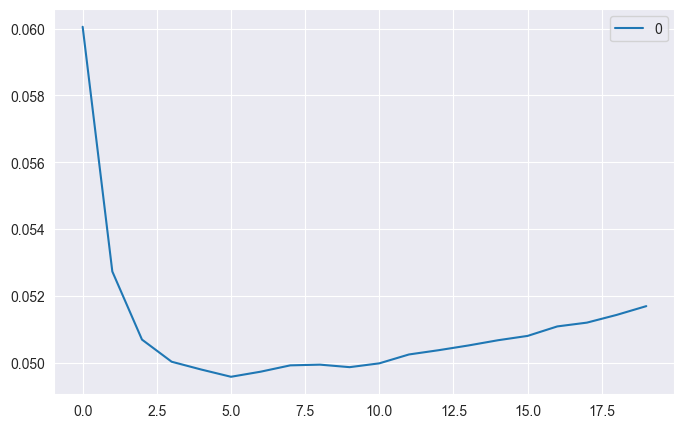

In [22]:
sns.set_style("darkgrid")
curve = pd.DataFrame(rmsle_val)
curve.plot(figsize=(8,5));
#plt.style.use("bmh")

In [23]:
knn = neighbors.KNeighborsRegressor(n_neighbors = best_k)

knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)
print("Puntaje test: ",knn.score(X_test, y_test))
print("Puntaje train: ",knn.score(X_train, y_train))

y_predtotal=knn.predict(X_final)
puntajetotal=knn.score(X_final,y)
print("Puntaje conjunto total: ", puntajetotal)

Puntaje test:  0.6096901738670664
Puntaje train:  0.7223975517089001
Puntaje conjunto total:  0.6885088648369043


In [24]:
# Ordenar los valores reales y mantener la relación con los predichos
sorted_indices_test = np.argsort(y_test)  # Obtener los índices ordenados de y_test
y_test_sorted = y_test[sorted_indices_test]  # Ordenar los valores reales
sorted_indices_pred = np.argsort(y_pred)
y_pred_sorted = y_pred[sorted_indices_pred]  # Reordenar las predicciones según esos índices
"""

fig, axs = plt.subplots(4, 1, figsize=(20, 15), sharex=True)

# --- Subplot 1: Datos de 0 a 550 ---
axs[0].plot(y_test_sorted[2:550], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)
axs[0].plot(y_pred_sorted[2:550], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)
axs[0].set_ylabel("Valor")
axs[0].set_title("Valores Reales vs. Predichos (0 - 600)")
axs[0].legend()
axs[0].grid()

# --- Subplot 2: Datos de 550 a 1100 ---
axs[1].plot(y_test_sorted[550:1100], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)
axs[1].plot(y_pred_sorted[550:1100], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)
axs[1].set_xlabel("Índice")
axs[1].set_ylabel("Valor")
axs[1].set_title("Valores Reales vs. Predichos (600 - 1200)")
axs[1].legend()
axs[1].grid()

# --- Subplot 3: Datos de 1100 a 1650 ---
axs[2].plot(y_test_sorted[1100:1650], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)
axs[2].plot(y_pred_sorted[1100:1650], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)
axs[2].set_xlabel("Índice")
axs[2].set_ylabel("Valor")
axs[2].set_title("Valores Reales vs. Predichos (1200 - 1800)")
axs[2].legend()
axs[2].grid()

# --- Subplot 4: Datos de 1650 a 2300 ---
axs[3].plot(y_test_sorted[1650:2300], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)
axs[3].plot(y_pred_sorted[1650:2300], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)
axs[3].set_xlabel("Índice")
axs[3].set_ylabel("Valor")
axs[3].set_title("Valores Reales vs. Predichos (1800 - 2400)")
axs[3].legend()
axs[3].grid()

# Ajustar los espacios entre subgráficos automáticamente
plt.tight_layout()
plt.show()
"""


'\n\nfig, axs = plt.subplots(4, 1, figsize=(20, 15), sharex=True)\n\n# --- Subplot 1: Datos de 0 a 550 ---\naxs[0].plot(y_test_sorted[2:550], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)\naxs[0].plot(y_pred_sorted[2:550], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)\naxs[0].set_ylabel("Valor")\naxs[0].set_title("Valores Reales vs. Predichos (0 - 600)")\naxs[0].legend()\naxs[0].grid()\n\n# --- Subplot 2: Datos de 550 a 1100 ---\naxs[1].plot(y_test_sorted[550:1100], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)\naxs[1].plot(y_pred_sorted[550:1100], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)\naxs[1].set_xlabel("Índice")\naxs[1].set_ylabel("Valor")\naxs[1].set_title("Valores Reales vs. Predichos (600 - 1200)")\naxs[1].legend()\naxs[1].grid()\n\n# --- Subplot 3: Datos de 1100 a 1650 ---\naxs[2].plot(y_test_sorted[1100:1650], lab

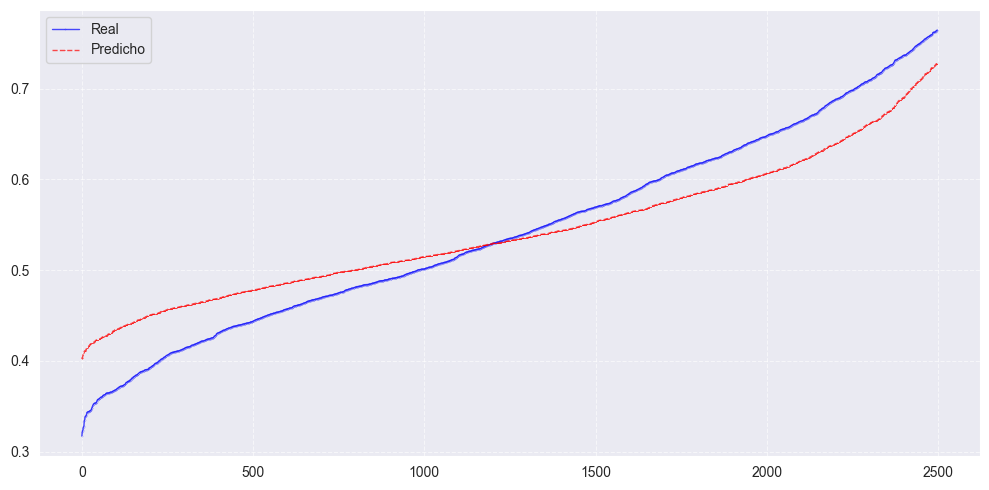

In [25]:

plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sorted[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

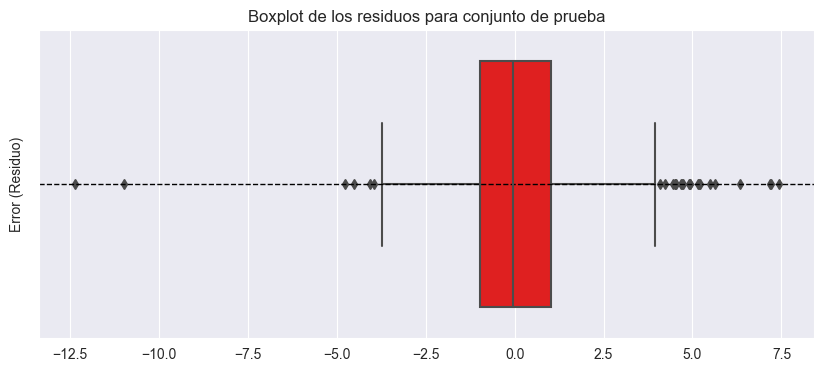

In [26]:
y_test_unscaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_unscaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
y_test_original = np.exp(y_test_unscaled)
y_pred_original = np.exp(y_pred_unscaled)

residuos = y_test_unscaled  - y_pred_unscaled  # Diferencia entre valores logaritmicos reales y predichos
residuosreales = y_test_original - y_pred_original

plt.figure(figsize=(10,4))
sns.boxplot(x=residuos, orient="h", color="red")
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)  # Línea en y=0
plt.ylabel("Error (Residuo)")
plt.title("Boxplot de los residuos para conjunto de prueba")

plt.show()



In [27]:
ylogreal = scaler_y.inverse_transform(y.reshape(-1, 1)).flatten()
ylogpred= scaler_y.inverse_transform(y_predtotal.reshape(-1, 1)).flatten()
residuos_log = ylogpred-ylogreal
yREAL = np.exp(ylogreal)
ypredREAL = np.exp(ylogpred)
residuos_totales = yREAL - ypredREAL

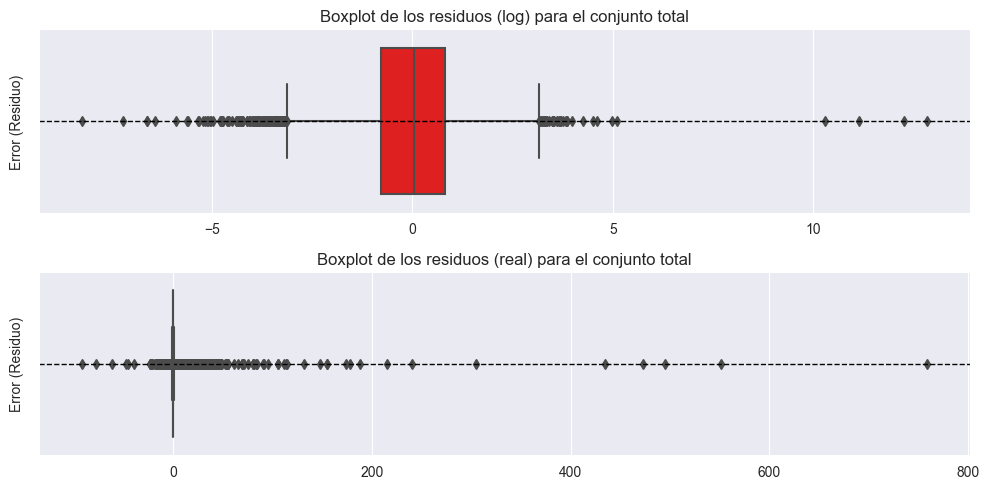

In [28]:

fig, axes = plt.subplots(2, 1, figsize=(10, 5))

sns.boxplot(x=residuos_log, orient="h", color="red", ax=axes[0])
axes[0].axhline(y=0, color="black", linestyle="--", linewidth=1)  
axes[0].set_ylabel("Error (Residuo)")
axes[0].set_title("Boxplot de los residuos (log) para el conjunto total")

sns.boxplot(x=residuos_totales, orient="h", color="red", ax=axes[1])
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1) 
axes[1].set_ylabel("Error (Residuo)")
axes[1].set_title("Boxplot de los residuos (real) para el conjunto total")

plt.tight_layout()

plt.show()
reKNN = pd.DataFrame({
    'Residuo Log': residuos_log,
    'Residuo Totales': residuos_totales
})

In [29]:
reKNN.describe()

,Residuo Log,Residuo Totales
count,8809.000000,8809.000000
mean,-0.017927,1.423989
std,1.301807,16.024048
min,-8.255347,-91.896531
25%,-0.773724,-0.057206
50%,0.044688,-0.002056
75%,0.801656,0.250743
max,12.850586,759.066624


## Regresiones

In [30]:
# Estandarizar datos
scaler_XRidge = MinMaxScaler()
scaler_yRidge = MinMaxScaler()
#df_numerico.drop(["Fault Plane (1; 2; X)"], axis=1, inplace=True) #Se va a codificar dsp.
# Escalar las variables predictoras
df_scaledRidge = pd.DataFrame(scaler_XRidge.fit_transform(df_numerico.drop("T_0.01_RotD50", axis=1)), 
                         columns=df_numerico.drop("T_0.01_RotD50", axis=1).columns)
# Escalar la variable de respuesta
Aceleracion_escalada = scaler_yRidge.fit_transform(df_numerico[["T_0.01_RotD50"]])  # Debe ser 2D
df_scaledRidge["T_0.01_RotD50"] = Aceleracion_escalada.flatten()

In [31]:
df_scaledRidge

,Hypocenter Depth (km),Magnitude,Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),Nodal Plane 1 Rake Angle (deg),Nodal Plane 2 Strike (deg),Nodal Plane 2 Dip (deg),Nodal Plane 2 Rake Angle (deg),Station Elevation (m),Repi_OpenQuake,Rjb_OpenQuake,Rrup_OpenQuake,Rx_OpenQuake,Rhypo_OpenQuake,Ry0_OpenQuake,T_0.01_RotD50
0,0.065582,0.519085,0.541899,0.910112,0.002778,0.294444,0.986842,0.481793,0.139642,0.049285,0.047258,0.041342,0.492622,0.043130,0.049300,0.727553
1,0.153662,0.315579,0.097765,0.595506,0.883333,0.430556,0.565789,0.630252,0.139642,0.051954,0.051893,0.048506,0.493464,0.048102,0.054087,0.770831
2,0.062231,0.557531,0.005587,0.707865,0.525000,0.750000,0.894737,0.932773,0.355276,0.098248,0.096107,0.090482,0.519776,0.091937,0.084880,0.728550
3,0.062231,0.616795,0.519553,0.471910,0.616667,0.177778,0.644737,0.851541,0.355276,0.138917,0.135183,0.129388,0.434061,0.132737,0.089607,0.677210
4,0.076592,0.586485,0.016760,0.719101,0.441667,0.297222,0.750000,0.075630,0.355276,0.075864,0.074332,0.068535,0.454221,0.069900,0.032669,0.763503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8804,0.019148,0.452011,0.935754,0.258427,0.655556,0.536111,0.736842,0.795518,0.167473,0.680668,0.681395,0.679396,0.845595,0.678214,0.216936,0.366315
8805,0.043083,0.305886,0.983240,0.224719,0.744444,0.488889,0.723684,0.759104,0.167473,0.690278,0.691650,0.689543,0.799038,0.687915,0.415149,0.344772
8806,0.220201,0.308975,0.927374,0.337079,0.708333,0.477778,0.605263,0.781513,0.167473,0.669863,0.671687,0.667973,0.840741,0.667859,0.207519,0.344306
8807,0.043083,0.308021,0.067039,0.348315,0.227778,0.597222,0.578947,0.266106,0.167473,0.401005,0.401675,0.397579,0.349570,0.396456,0.319876,0.442509


In [32]:
X_numericalRidge = df_scaledRidge.drop(columns=["T_0.01_RotD50"]).values
yRidge = df_scaledRidge["T_0.01_RotD50"].values

In [33]:
# Paso 3: Combinar características numéricas y codificadas
X_finalRidge = np.hstack((X_numericalRidge, X_encoded,Y_encoded,Z_encoded))

In [34]:
X_trainRidge, X_testRidge, y_trainRidge, y_testRidge = train_test_split(X_finalRidge, yRidge, test_size=0.3, random_state=0)

### Regresión Lineal estándar

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [36]:
lr = LinearRegression().fit(X_trainRidge, y_trainRidge)
y_pred_reglineal = lr.predict(X_testRidge)

In [37]:
print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))

lr.coef_: [-8.09360030e-02  2.18612201e-01 -1.20543608e-03 -7.81037165e-03
 -7.82133358e-03 -9.03044103e-03  4.16525707e-03 -5.01911585e-03
 -2.89163843e-03  5.71764057e+00 -7.72824249e+00  2.40714995e+00
 -1.95166568e-02 -7.30661430e-01  3.58547444e-03 -1.24516585e-03
  3.80437516e-02  2.15882815e-03 -3.89574139e-02 -1.41786322e-04
  1.41786323e-04 -8.74719999e-03  2.89704269e-03  5.85015729e-03]
lr.intercept_: 0.6264562929231874


In [38]:
print("Training set score: {:.2f}".format(lr.score(X_trainRidge, y_trainRidge)))
print("Test set score: {:.2f}".format(lr.score(X_testRidge, y_testRidge)))

Training set score: 0.54
Test set score: 0.51


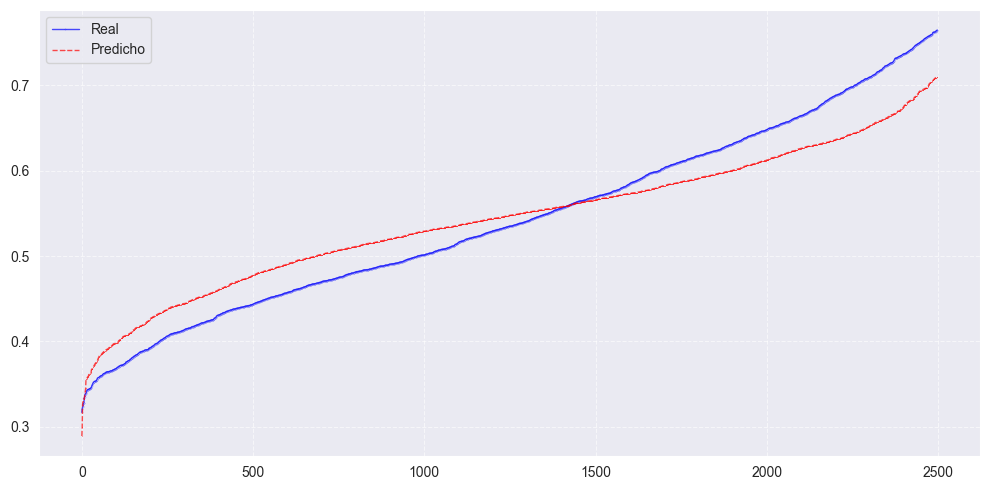

In [39]:
sorted_indices_pred = np.argsort(y_pred_reglineal)
y_pred_sorted_reglineal = y_pred_reglineal[sorted_indices_pred]  # Reordenar las predicciones según esos índices
plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sorted_reglineal[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regresión Ridge

In [40]:
from sklearn.linear_model import Ridge

In [41]:
ridge = Ridge(alpha=10).fit(X_trainRidge, y_trainRidge)
print("Training set score: {:.2f}".format(ridge.score(X_trainRidge, y_trainRidge)))
print("Test set score: {:.2f}".format(ridge.score(X_testRidge, y_testRidge)))

Training set score: 0.51
Test set score: 0.48


In [42]:
y_pred_Ridge = ridge.predict(X_testRidge)

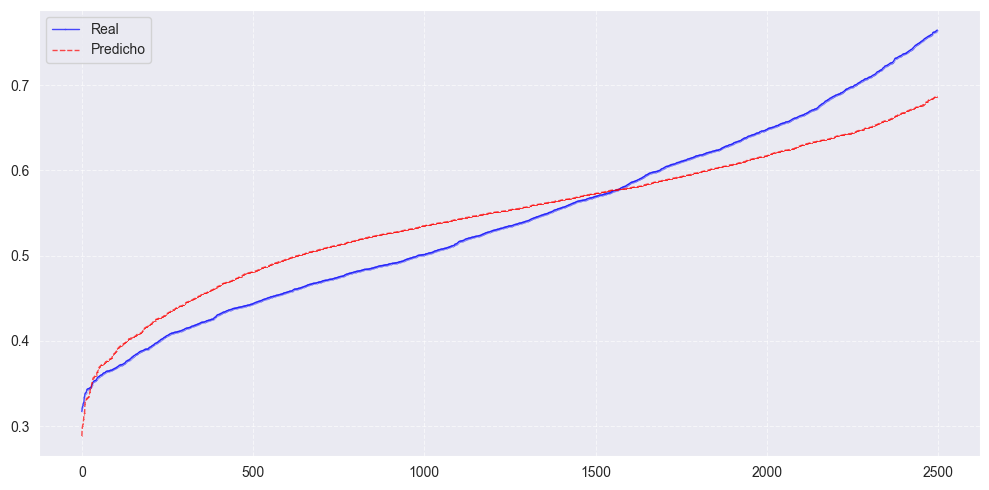

In [43]:
sorted_indices_predRidge = np.argsort(y_pred_Ridge)
y_pred_sorted_Ridge = y_pred_Ridge[sorted_indices_predRidge]  # Reordenar las predicciones según esos índices
plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sorted_Ridge[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regresión Lasso

In [44]:
from sklearn.linear_model import Lasso
lasso = Lasso().fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso.coef_ != 0)))

Training set score: 0.00
Test set score: -0.00
Number of features used: 0


In [45]:
lasso001 = Lasso(alpha=0.001, max_iter=10000000).fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso001.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso001.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso001.coef_ != 0)))

Training set score: 0.51
Test set score: 0.47
Number of features used: 6


In [46]:
y_pred_Lasso= lasso001.predict(X_test)


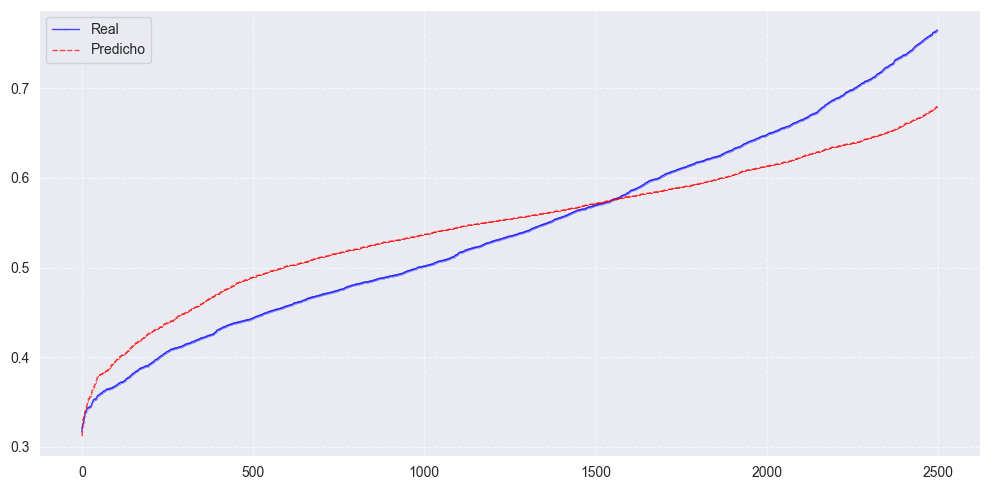

In [47]:
sorted_indices_predLasso = np.argsort(y_pred_Lasso)
y_pred_sorted_Lasso = y_pred_Lasso[sorted_indices_predLasso]  # Reordenar las predicciones según esos índices
plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sorted_Lasso[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Árboles de decisión

### Random Forest

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

In [49]:
X_trainRAND, X_testRAND, y_trainRAND, y_testRAND = train_test_split(X_finalRidge, yRidge, test_size=0.3, random_state=0,)


In [50]:
randforreg = RandomForestRegressor(n_estimators=100, criterion='squared_error', max_depth=7, min_samples_split=2, min_samples_leaf=1,
                                   min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True,
                                   oob_score=False, n_jobs=None, random_state=0, verbose=0, warm_start=False, ccp_alpha=0.0, max_samples=None,
                                   monotonic_cst=None)

In [51]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'min_samples_split': [2, 5, 10, 20],  # Valores más altos = menos splits
    'min_samples_leaf': [1, 2, 4, 8],  # Valores altos = más generalización

}

grid = GridSearchCV(randforreg, param_grid, scoring='r2', cv=3, n_jobs=7)
grid.fit(X_trainRAND, y_trainRAND)

print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'min_samples_leaf': 1, 'min_samples_split': 2}


In [52]:
randforreg.fit(X_trainRAND, y_trainRAND)

RandomForestRegressor(max_depth=7, random_state=0)

In [53]:
y_predRAND = randforreg.predict(X_testRAND)

In [54]:
print("Training set score: {:.2f}".format(randforreg.score(X_trainRAND, y_trainRAND)))
print("Test set score: {:.2f}".format(randforreg.score(X_testRAND, y_testRAND)))
print("Total score: {:.2f}".format(randforreg.score(X_finalRidge, yRidge)))

Training set score: 0.76
Test set score: 0.71
Total score: 0.74


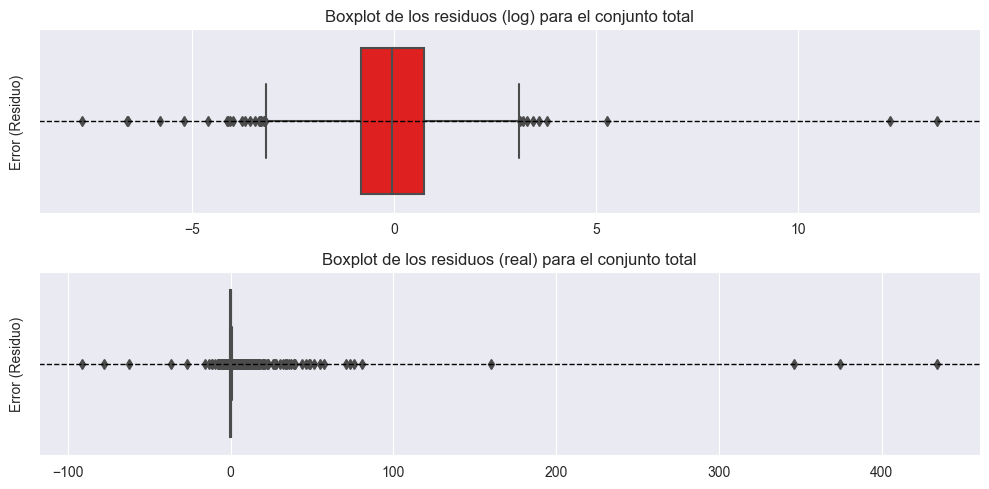

In [55]:
ylogrealRANDOM = scaler_y.inverse_transform(y_testRAND.reshape(-1, 1)).flatten()
ylogpredRANDOM= scaler_y.inverse_transform(y_predRAND.reshape(-1, 1)).flatten()
residuos_logRANDOM = ylogpredRANDOM-ylogrealRANDOM
yREALRANDOM = np.exp(ylogrealRANDOM)
ypredREALRANDOM = np.exp(ylogpredRANDOM)
residuos_totalesRANDOM = yREALRANDOM - ypredREALRANDOM

residuosRANDOM = y_test_unscaled  - y_pred_unscaled  # Diferencia entre valores logaritmicos reales y predichos
residuosrealesRANDOM = y_test_original - y_pred_original

fig, axes = plt.subplots(2, 1, figsize=(10, 5))

sns.boxplot(x=residuos_logRANDOM, orient="h", color="red", ax=axes[0])
axes[0].axhline(y=0, color="black", linestyle="--", linewidth=1)  
axes[0].set_ylabel("Error (Residuo)")
axes[0].set_title("Boxplot de los residuos (log) para el conjunto total")

sns.boxplot(x=residuos_totalesRANDOM, orient="h", color="red", ax=axes[1])
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1) 
axes[1].set_ylabel("Error (Residuo)")
axes[1].set_title("Boxplot de los residuos (real) para el conjunto total")

plt.tight_layout()

plt.show()
reRANDOM = pd.DataFrame({
    'Residuo Log': residuos_logRANDOM,
    'Residuo Totales': residuos_totalesRANDOM
})

In [56]:
print(ylogpredRANDOM.shape)  # Ver el tamaño del array predicho
print(ylogrealRANDOM.shape)  # Ver el tamaño del array real


(2643,)
(2643,)


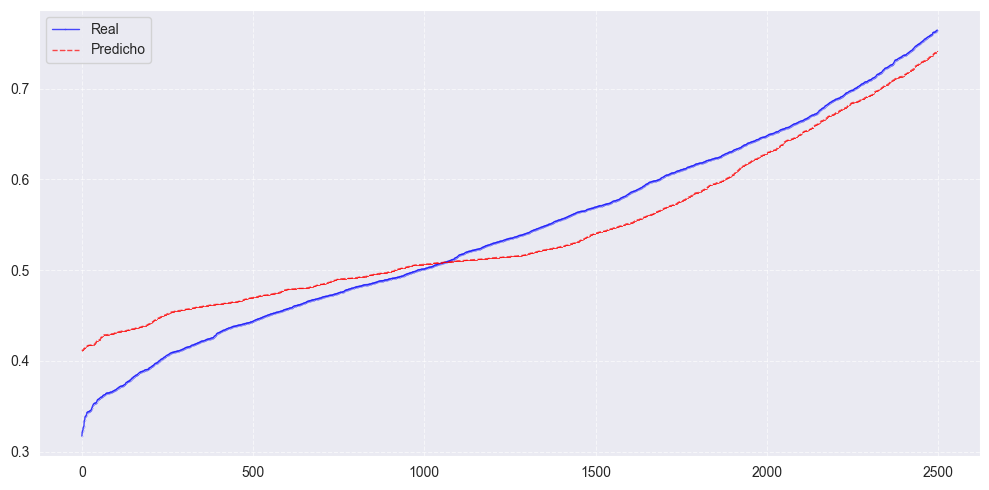

In [57]:
sorted_indices_predRAND= np.argsort(y_predRAND)
y_pred_sortedRAND = y_predRAND[sorted_indices_predRAND]  # Reordenar las predicciones según esos índices
plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sortedRAND[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### XGBoost

In [58]:
import xgboost as xgb
from xgboost import XGBRegressor
print(xgb.build_info())


{'BUILTIN_PREFETCH_PRESENT': False, 'CUDA_VERSION': [12, 4], 'DEBUG': False, 'MM_PREFETCH_PRESENT': True, 'THRUST_VERSION': [2, 3, 2], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': False, 'USE_FEDERATED': False, 'USE_NCCL': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': 'C:\\Users\\elias\\AppData\\Roaming\\Python\\Python39\\site-packages\\xgboost\\lib\\xgboost.dll'}


In [59]:
X_XGB=df_scaled.copy()
X_XGB['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)'] = df_copy['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)']
X_XGB['Fault Plane (1; 2; X)'] = df_copy['Fault Plane (1; 2; X)']
X_XGB['Style-of-Faulting (S; R; N; U)'] = df_copy['Style-of-Faulting (S; R; N; U)']
X_XGB[categorical_columns] = X[categorical_columns].astype('category')

In [60]:
Y_XGB=X_XGB[["T_0.01_RotD50"]].copy()
X_XGB.drop(["T_0.01_RotD50"],axis=1, inplace=True )

In [61]:
XGBRegressor(tree_method='gpu_hist', gpu_id=1)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, ...)

In [62]:
X_trainXGB, X_testXGB, y_trainXGB, y_testXGB = train_test_split(X_XGB, Y_XGB, test_size=0.3, random_state=42)

# Modelo con GPU
modelXGB = XGBRegressor(tree_method="gpu_hist", gpu_id=1, enable_categorical=True, n_estimators=1000, max_depth=6, gamma=0,
                        reg_lambda = 10, reg_alpha= 0.1)
modelXGB.fit(X_trainXGB, y_trainXGB)

# Predicciones
y_predXGB = modelXGB.predict(X_testXGB)

In [63]:
"""from sklearn.model_selection import GridSearchCV

param_gridXGB = {
    'gamma': [0, 0.001, 0.01, 0.1],
    'reg_lambda': [0.1,1,10,100],
    'reg_alpha' : [0.1,1,10,100],
    'max_depth' : [6,7,8,9]
}

grid = GridSearchCV(modelXGB, param_gridXGB, scoring='r2', cv=3, n_jobs=7)
grid.fit(X_trainXGB, y_trainXGB)

print("Mejores parámetros:", grid.best_params_)"""

'from sklearn.model_selection import GridSearchCV\n\nparam_gridXGB = {\n    \'gamma\': [0, 0.001, 0.01, 0.1],\n    \'reg_lambda\': [0.1,1,10,100],\n    \'reg_alpha\' : [0.1,1,10,100],\n    \'max_depth\' : [6,7,8,9]\n}\n\ngrid = GridSearchCV(modelXGB, param_gridXGB, scoring=\'r2\', cv=3, n_jobs=7)\ngrid.fit(X_trainXGB, y_trainXGB)\n\nprint("Mejores parámetros:", grid.best_params_)'

In [64]:
print("Train set : ",modelXGB.score(X_trainXGB, y_trainXGB))
print("Test set : ",modelXGB.score(X_testXGB, y_testXGB))

Train set :  0.9776307940483093
Test set :  0.8337039947509766


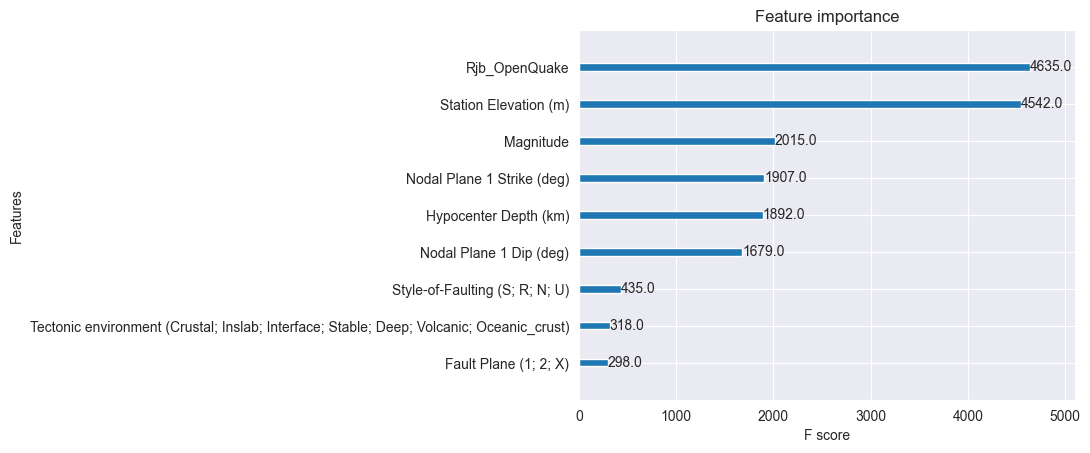

In [65]:
xgb.plot_importance(modelXGB)
plt.show()

In [78]:

# Conversión directa con np.array()
y_test_array = np.array(y_testXGB['T_0.01_RotD50'])  # DataFrame -> Array
y_pred_array = np.array(y_predXGB)  # Series -> Array
# Ordenar los valores reales y mantener la relación con los predichos
sorted_indices = np.argsort(y_test_array)  # Obtener los índices ordenados de y_test
y_test_sortedXGB = y_test_array[sorted_indices]  # Ordenar los valores reales
sorted_indices2 = np.argsort(y_pred_array) 
y_pred_sortedXGB = y_pred_array[sorted_indices2]  # Reordenar las predicciones según esos índices


"""fig, axs = plt.subplots(4, 1, figsize=(20, 15), sharex=True)

# --- Subplot 1: Datos de 0 a 550 ---
axs[0].plot(y_test_sortedXGB[2:550], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)
axs[0].plot(y_pred_sortedXGB[2:550], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)
axs[0].set_ylabel("Valor")
axs[0].set_title("Valores Reales vs. Predichos (0 - 600)")
axs[0].legend()
axs[0].grid()

# --- Subplot 2: Datos de 550 a 1100 ---
axs[1].plot(y_test_sortedXGB[550:1100], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)
axs[1].plot(y_pred_sortedXGB[550:1100], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)
axs[1].set_xlabel("Índice")
axs[1].set_ylabel("Valor")
axs[1].set_title("Valores Reales vs. Predichos (600 - 1200)")
axs[1].legend()
axs[1].grid()

# --- Subplot 3: Datos de 1100 a 1650 ---
axs[2].plot(y_test_sortedXGB[1100:1650], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)
axs[2].plot(y_pred_sortedXGB[1100:1650], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)
axs[2].set_xlabel("Índice")
axs[2].set_ylabel("Valor")
axs[2].set_title("Valores Reales vs. Predichos (1200 - 1800)")
axs[2].legend()
axs[2].grid()

# --- Subplot 4: Datos de 1650 a 2300 ---
axs[3].plot(y_test_sortedXGB[1650:2300], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)
axs[3].plot(y_pred_sortedXGB[1650:2300], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)
axs[3].set_xlabel("Índice")
axs[3].set_ylabel("Valor")
axs[3].set_title("Valores Reales vs. Predichos (1800 - 2400)")
axs[3].legend()
axs[3].grid()

# Ajustar los espacios entre subgráficos automáticamente
plt.tight_layout()
plt.show()"""

'fig, axs = plt.subplots(4, 1, figsize=(20, 15), sharex=True)\n\n# --- Subplot 1: Datos de 0 a 550 ---\naxs[0].plot(y_test_sortedXGB[2:550], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)\naxs[0].plot(y_pred_sortedXGB[2:550], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)\naxs[0].set_ylabel("Valor")\naxs[0].set_title("Valores Reales vs. Predichos (0 - 600)")\naxs[0].legend()\naxs[0].grid()\n\n# --- Subplot 2: Datos de 550 a 1100 ---\naxs[1].plot(y_test_sortedXGB[550:1100], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1)\naxs[1].plot(y_pred_sortedXGB[550:1100], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1)\naxs[1].set_xlabel("Índice")\naxs[1].set_ylabel("Valor")\naxs[1].set_title("Valores Reales vs. Predichos (600 - 1200)")\naxs[1].legend()\naxs[1].grid()\n\n# --- Subplot 3: Datos de 1100 a 1650 ---\naxs[2].plot(y_test_sortedXGB[1100

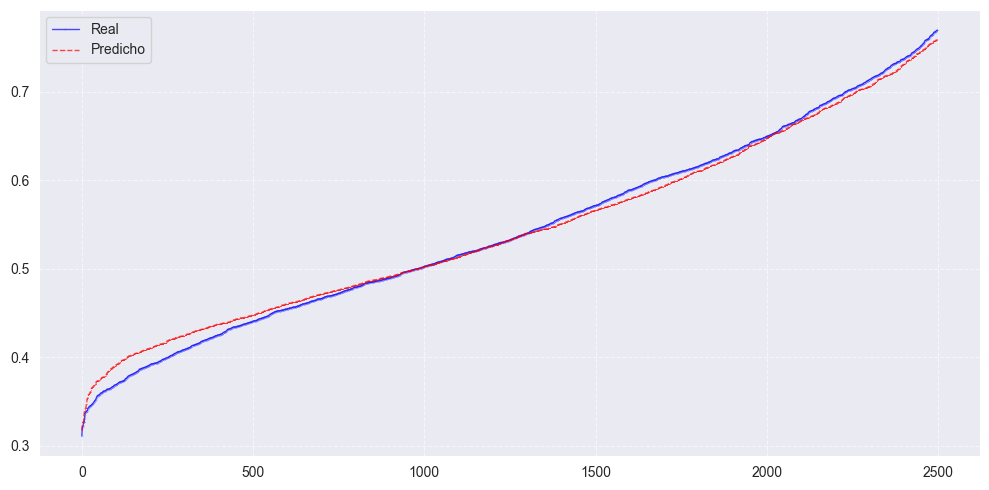

In [79]:

plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sortedXGB[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sortedXGB[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## SVM

In [68]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error


In [69]:
"""from sklearn.model_selection import GridSearchCV

param_grid = {'C': np.logspace(-3, 3, 7)}  

grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

print("Mejor C:", grid_search.best_params_['C'])
"""


'from sklearn.model_selection import GridSearchCV\n\nparam_grid = {\'C\': np.logspace(-3, 3, 7)}  \n\ngrid_search = GridSearchCV(SVR(kernel=\'rbf\'), param_grid, cv=5, scoring=\'neg_mean_squared_error\')\ngrid_search.fit(X_train, y_train)\n\nprint("Mejor C:", grid_search.best_params_[\'C\'])\n'

In [70]:
svr_lineal = SVR(kernel='linear', C=1, epsilon=0.1) 
svr_lineal.fit(X_train,y_train)


SVR(C=1, kernel='linear')

In [71]:
svr_poly = SVR(kernel='poly', C=1.0, epsilon=0.1) 
svr_poly.fit(X_train,y_train)

SVR(kernel='poly')

In [72]:
svr_rbf = SVR(kernel='rbf', C=10, epsilon=0.1) 
svr_rbf.fit(X_train,y_train)

SVR(C=10)

In [73]:
y_pred_svm= svr_rbf.predict(X_test)

In [74]:
print("Puntaje entrenamiento para svm con kernel lineal:" ,svr_lineal.score(X_train, y_train))
print("Puntaje test para svm con kernel lineal:" ,svr_lineal.score(X_test, y_test))
print("Puntaje entrenamiento para svm con kernel poly:" ,svr_poly.score(X_train, y_train))
print("Puntaje test para svm con kernel poly:" ,svr_poly.score(X_test, y_test))
print("Puntaje entrenamiento para svm con kernel rbf:" ,svr_rbf.score(X_train, y_train))
print("Puntaje test para svm con kernel rbf:" ,svr_rbf.score(X_test, y_test))

Puntaje entrenamiento para svm con kernel lineal: 0.5118653186082465
Puntaje test para svm con kernel lineal: 0.4764301720694918
Puntaje entrenamiento para svm con kernel poly: 0.6565885999244516
Puntaje test para svm con kernel poly: 0.6353856191488072
Puntaje entrenamiento para svm con kernel rbf: 0.6723342278925559
Puntaje test para svm con kernel rbf: 0.6418017784080997


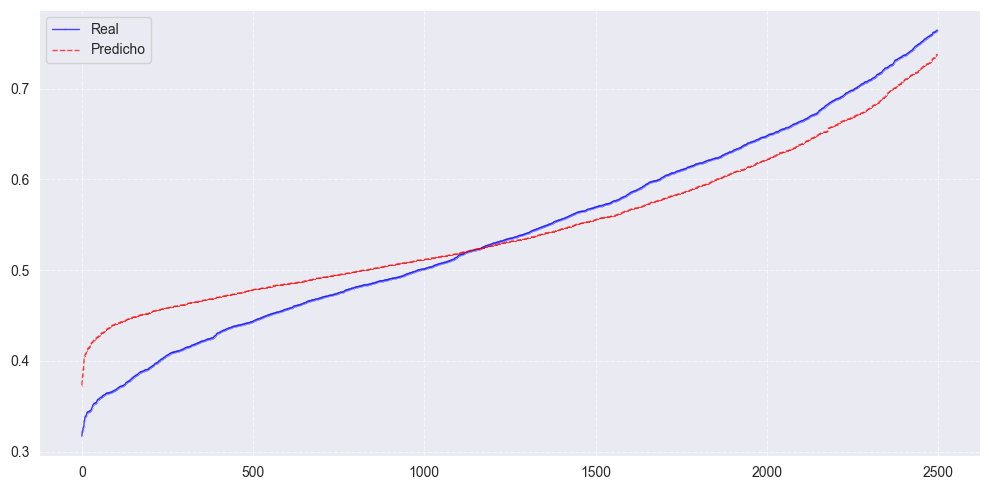

In [75]:
sorted_indices_predSVM= np.argsort(y_pred_svm)
y_pred_sortedSVM = y_pred_svm[sorted_indices_predSVM]  # Reordenar las predicciones según esos índices
plt.figure(figsize=(10,5))

# Graficar datos reales y predichos
plt.plot(y_test_sorted[2:2500], label="Real", marker="o", linestyle="-", color="blue", markersize=0.1, linewidth=1, alpha=0.7)
plt.plot(y_pred_sortedSVM[2:2500], label="Predicho", marker="x", linestyle="--", color="red", markersize=0.1, linewidth=1, alpha=0.7)

plt.legend(["Real", "Predicho"])  
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Tabla de métricas

In [99]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox


epsilon = 1e-6  # Pequeño valor para evitar divisiones por cero
#MAPE
mape_knn = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_knn) * 100
mape_regl = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_reglineal) * 100
mape_ridge = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_Ridge) * 100
mape_lasso = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_Lasso) * 100
mape_rand = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_predRAND) * 100
mape_xgb = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_predXGB) * 100
mape_svm = mean_absolute_percentage_error(np.maximum(y_test, epsilon), y_pred_svm) * 100


#RMSE
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))  # RMSE
rmse_regl = np.sqrt(mean_squared_error(y_test, y_pred_reglineal))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_Ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_Lasso))
rmse_rand = np.sqrt(mean_squared_error(y_test, y_predRAND))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_predXGB))
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))


#R2

r2_knn = r2_score(y_test, y_pred_knn)  # R²
r2_regl = r2_score(y_test, y_pred_reglineal)  # R²
r2_ridge = r2_score(y_test, y_pred_Ridge)  # R²
r2_lasso = r2_score(y_test, y_pred_Lasso)  # R²
r2_rand = r2_score(y_test, y_predRAND)  # R²
r2_xgb = r2_score(y_testXGB, y_predXGB)
r2_svm = r2_score(y_test, y_pred_svm)  # R²

# Calcular Ljung-Box (test de autocorrelación de residuos)
residuos_knn = y_test - y_pred_knn
ljung_box_knn = acorr_ljungbox(residuos_knn, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_regl = y_test - y_pred_reglineal
ljung_box_regl = acorr_ljungbox(residuos_regl, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_ridge = y_test - y_pred_Ridge
ljung_box_ridge = acorr_ljungbox(residuos_ridge, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_lasso = y_test - y_pred_Lasso
ljung_box_lasso = acorr_ljungbox(residuos_lasso, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_rand = y_test - y_predRAND
ljung_box_rand = acorr_ljungbox(residuos_rand, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_xgb = y_test - y_predXGB
ljung_box_xgb = acorr_ljungbox(residuos_xgb, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value
residuos_svm = y_test - y_pred_svm
ljung_box_svm = acorr_ljungbox(residuos_svm, lags=1, return_df=True)['lb_pvalue'].iloc[0]  # p-value

# Calcular Jarque-Bera (test de normalidad de residuos)
jb_test_knn = jarque_bera(residuos_knn)
jarque_bera_knn = jb_test_knn.pvalue  # p-value
jb_test_regl = jarque_bera(residuos_regl)
jarque_bera_regl = jb_test_regl.pvalue
jb_test_ridge = jarque_bera(residuos_ridge)
jarque_bera_ridge = jb_test_ridge.pvalue
jb_test_lasso = jarque_bera(residuos_lasso)
jarque_bera_lasso = jb_test_lasso.pvalue
jb_test_rand = jarque_bera(residuos_rand)
jarque_bera_rand = jb_test_rand.pvalue
jb_test_xgb = jarque_bera(residuos_xgb)
jarque_bera_xgb = jb_test_xgb.pvalue
jb_test_svm = jarque_bera(residuos_svm)
jarque_bera_svm = jb_test_svm.pvalue


tabla_resultados = pd.DataFrame({
    'Modelo': ['K-NN','Regresión Lineal','Regresión Ridge','Regresión Lasso','Random Forest','XGBoost','SVM'],
    'MAPE (%)': [mape_knn, mape_regl, mape_ridge, mape_lasso, mape_rand, mape_xgb, mape_svm],
    'RMSE': [rmse_knn, rmse_regl, rmse_ridge, rmse_lasso, rmse_rand, rmse_xgb, rmse_svm],
    'R²': [r2_knn, r2_regl, r2_ridge, r2_lasso, r2_rand, r2_xgb, r2_svm],
    'Ljung-Box p-value': [ljung_box_knn, ljung_box_regl, ljung_box_ridge, ljung_box_lasso, ljung_box_rand, ljung_box_xgb, ljung_box_svm],
    'Jarque-Bera p-value': [jarque_bera_knn, jarque_bera_regl, jarque_bera_ridge, jarque_bera_lasso, jarque_bera_rand, jarque_bera_xgb, jarque_bera_svm]
})



In [100]:
tabla_resultados

,Modelo,MAPE (%),RMSE,R²,Ljung-Box p-value,Jarque-Bera p-value
0,K-NN,11.386204,0.076226,0.609690,0.084624,0.000000e+00
1,Regresión Lineal,13.160224,0.085645,0.507270,0.041566,2.386578e-114
2,Regresión Ridge,13.628344,0.088119,0.478396,0.024577,5.128665e-100
3,Regresión Lasso,13.717536,0.088421,0.474819,0.018071,4.150515e-72
4,Random Forest,10.099874,0.065922,0.708086,0.374587,0.000000e+00
5,XGBoost,25.171569,0.165248,0.833704,0.856885,4.856035e-03
6,SVM,11.207120,0.073023,0.641802,0.333471,0.000000e+00


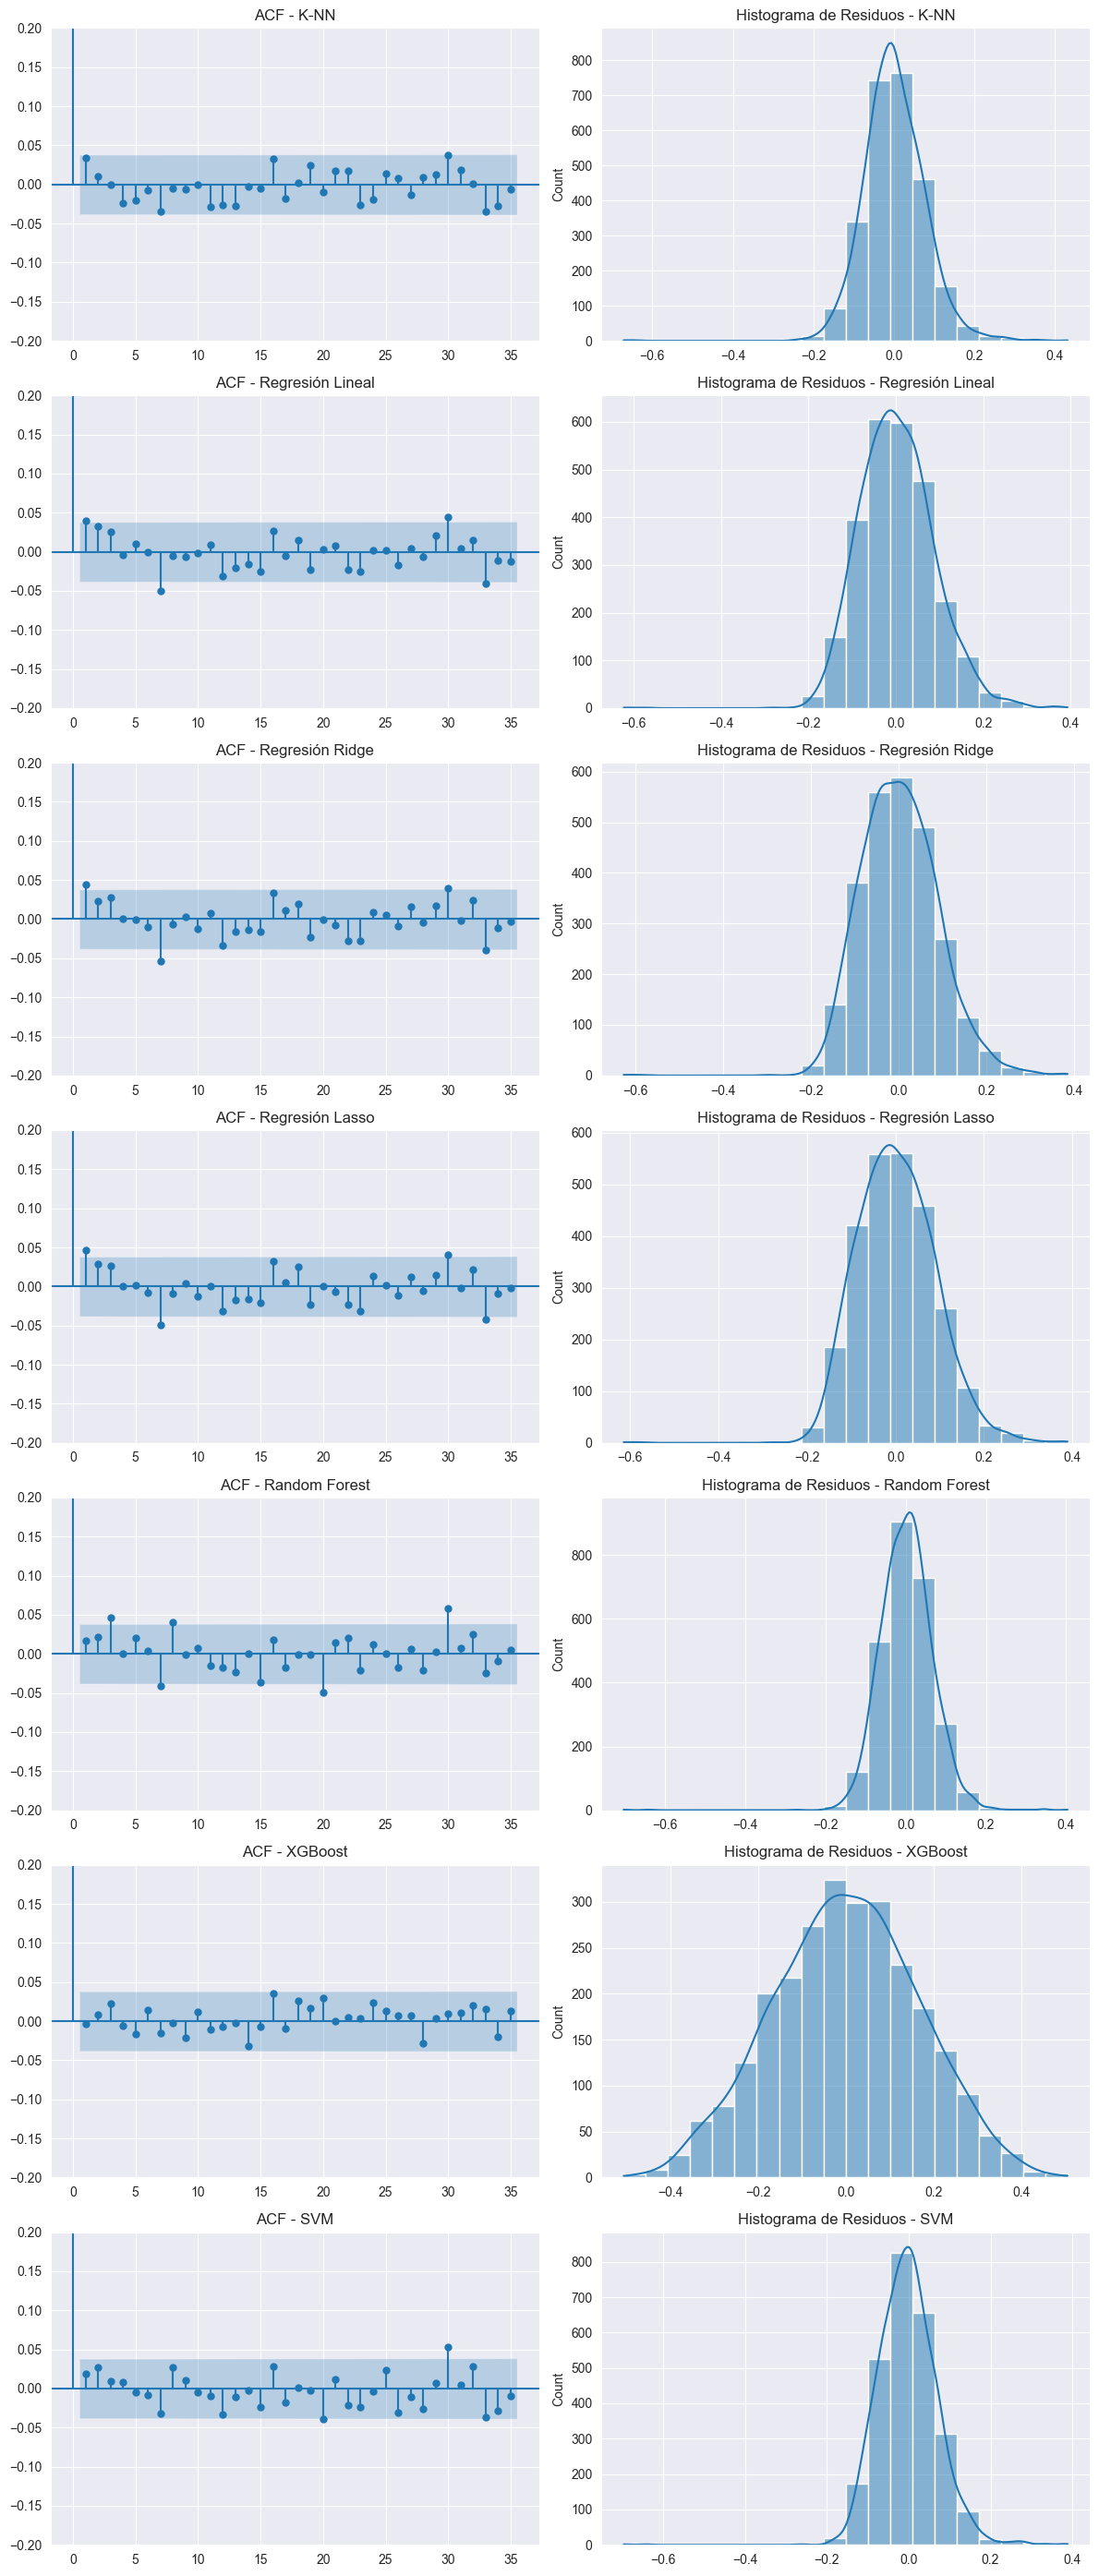

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

modelos = {
    "K-NN": residuos_knn,
    "Regresión Lineal": residuos_regl,
    "Regresión Ridge": residuos_ridge,
    "Regresión Lasso": residuos_lasso,
    "Random Forest": residuos_rand,
    "XGBoost": residuos_xgb,
    "SVM": residuos_svm
}

fig, axes = plt.subplots(len(modelos), 2, figsize=(12, 4 * len(modelos)))

for i, (nombre, residuos) in enumerate(modelos.items()):
    # ACF de los residuos
    plot_acf(residuos, ax=axes[i, 0], title=f"ACF - {nombre}")
    axes[i,0].set_ylim(-0.2, 0.2)  # Límite en el eje y
    # Histograma de los residuos
    sns.histplot(residuos, bins=20, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"Histograma de Residuos - {nombre}")
    

plt.tight_layout()
plt.show()
